# Sensitivitätsanalyse: Nachhaltige Verkehrsmittelwahl (Sustainable Freight Mode Choice)

Dieses Notebook führt eine systematische Sensitivitätsanalyse für unser multimodales Routing-Modell durch. Wir untersuchen, wie sich Änderungen in den Modellparametern auf die Verkehrsmittelwahl (Modal Split), die Gesamtkosten und die CO₂-Emissionen auswirken.

Folgende drei Experimente werden durchgeführt:
1. **Variation der Zielgewichtung (Kosten vs. Emissionen):** Untersuchung des Trade-offs (Pareto-Front) und der Verschiebung des Modal Splits bei steigender ökologischer Gewichtung.
2. **Impliziter CO₂-Preis (Carbon Tax):** Analyse der Lenkungswirkung einer CO₂-Abgabe durch das Verhältnis von Emissionsgewicht zu Kostengewicht.
3. **Lieferfristen (Deadlines):** Untersuchung der Auswirkungen von Zeitdruck (tightere Deadlines) auf die Machbarkeit und den erzwungenen Modal Shift hin zu schnelleren Verkehrsträgern.

## 1. Setup und Imports

In [9]:
import sys
import time
import random
import math
from pathlib import Path
from collections import defaultdict
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from freight_routing.data_loader import NetworkDataLoader
from freight_routing.data_models import Shipment, ObjectiveWeights, ArcType
from freight_routing.model import TimeExpandedNetwork
from heuristics.dijkstra_router import AStarRouter

sns.set_theme(style="whitegrid", palette="muted")

## 2. Laden des Netzwerks und Generieren einer Testinstanz

Wir nutzen eine mittlere Testinstanz mit 50 Sendungen, um eine schnelle und interaktive Berechnung aller Szenarien zu ermöglichen.

In [10]:
network_path = PROJECT_ROOT / "dataset/large_network.json"
network_data = NetworkDataLoader.from_json(network_path)

# Generierung von 50 konsistenten Test-Sendungen
random.seed(42)
N_SHIPMENTS = 50
PLANNING_DAYS = 30
DEFAULT_DEADLINE = PLANNING_DAYS * 24 * 60

hubs_list = list(network_data.hubs.keys())
shipments_base = []
for i in range(N_SHIPMENTS):
    start = random.choice(hubs_list)
    dest = random.choice(hubs_list)
    while dest == start:
        dest = random.choice(hubs_list)
        
    shipments_base.append(
        Shipment(
            id=f"shipment_{i}",
            start_hub=start,
            end_hub=dest,
            start_time=0,
            deadline=DEFAULT_DEADLINE,
            max_price=1000000.0,
            max_emissions=None,
            weight=float(random.randint(1, 10)),
            objective_weights=ObjectiveWeights(cost=0.5, time=0.3, emissions=0.2)  # Wird im Loop angepasst
        )
    )
print(f"{len(shipments_base)} Basis-Sendungen generiert.")

50 Basis-Sendungen generiert.


## 3. Hilfsfunktion zur Auswertung des Modal Splits

Wir messen den Modal Split anhand der geleisteten Tonnenkilometer (Gewicht * Distanz) je Transportmodus.

In [11]:
def calculate_modal_split(result, shipments):
    shipments_by_id = {s.id: s for s in shipments}
    mode_ton_km = defaultdict(float)
    
    for s_id, route in result.shipment_routes.items():
        shipment = shipments_by_id[s_id]
        for arc in route:
            if arc.arc_type == ArcType.TRANSPORT:
                mode_ton_km[arc.mode] += shipment.weight * arc.distance
                
    total_ton_km = sum(mode_ton_km.values())
    if total_ton_km == 0:
        return {"road": 0.0, "rail": 0.0, "air": 0.0, "total": 0.0}
        
    return {
        "road": (mode_ton_km["road"] / total_ton_km) * 100,
        "rail": (mode_ton_km["rail"] / total_ton_km) * 100,
        "air": (mode_ton_km["air"] / total_ton_km) * 100,
        "total": total_ton_km
    }

## 4. Experiment 1: Variation der Zielgewichtung (Kosten vs. Emissionen)

Wir halten das Zeitgewicht bei $w_{\text{time}} = 0.2$ konstant und variieren das Gewicht für Emissionen $w_{\text{emissions}}$ von $0.0$ (reine Kostenoptimierung) bis $0.8$ (maximale CO₂-Minimierung). Das Kostengewicht ergibt sich aus $w_{\text{cost}} = 0.8 - w_{\text{emissions}}$.

In [12]:
results_weights = []
w_emissions_range = np.round(np.arange(0.0, 0.81, 0.1), 2)

for w_e in w_emissions_range:
    w_c = round(0.8 - w_e, 2)
    weights = ObjectiveWeights(cost=w_c, time=0.2, emissions=w_e)
    
    # Sendungen mit angepassten Gewichten instanziieren
    test_shipments = []
    for s in shipments_base:
        test_shipments.append(
            Shipment(
                id=s.id,
                start_hub=s.start_hub,
                end_hub=s.end_hub,
                start_time=s.start_time,
                deadline=s.deadline,
                max_price=s.max_price,
                max_emissions=s.max_emissions,
                weight=s.weight,
                objective_weights=weights
            )
        )
        
    network = TimeExpandedNetwork.build(network_data, planning_days=PLANNING_DAYS, shipments=test_shipments)
    router = AStarRouter(weights)
    
    t_start = time.time()
    res = router.solve_multiple(network)
    duration = time.time() - t_start
    
    split = calculate_modal_split(res, test_shipments)
    
    results_weights.append({
        "w_emissions": w_e,
        "w_cost": w_c,
        "total_cost": res.total_cost,
        "total_emissions": res.total_emissions,
        "solved_pct": (len(res.shipment_routes) / len(test_shipments)) * 100,
        "road_share": split["road"],
        "rail_share": split["rail"],
        "air_share": split["air"],
        "total_ton_km": split["total"],
        "duration": duration
    })
    print(f"Gewichte berechnet: cost={w_c:.1f}, emissions={w_e:.1f} -> Rail share: {split['rail']:.1f}%")

df_weights = pd.DataFrame(results_weights)

Gewichte berechnet: cost=0.8, emissions=0.0 -> Rail share: 0.0%
Gewichte berechnet: cost=0.7, emissions=0.1 -> Rail share: 0.0%
Gewichte berechnet: cost=0.6, emissions=0.2 -> Rail share: 0.0%
Gewichte berechnet: cost=0.5, emissions=0.3 -> Rail share: 0.0%
Gewichte berechnet: cost=0.4, emissions=0.4 -> Rail share: 0.0%
Gewichte berechnet: cost=0.3, emissions=0.5 -> Rail share: 0.0%
Gewichte berechnet: cost=0.2, emissions=0.6 -> Rail share: 0.0%
Gewichte berechnet: cost=0.1, emissions=0.7 -> Rail share: 0.0%
Gewichte berechnet: cost=0.0, emissions=0.8 -> Rail share: 0.0%


### Visualisierung der Ergebnisse von Experiment 1

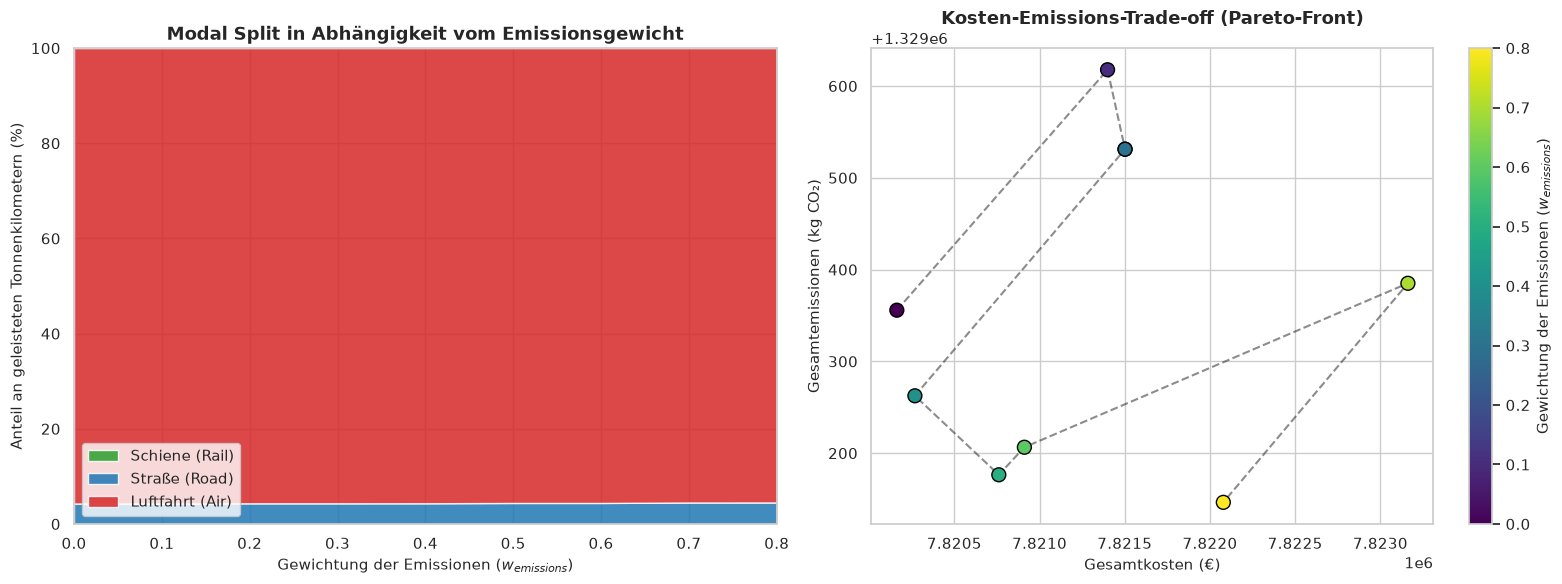

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Modal Split vs. Emissionsgewicht (Stacked Area Chart)
axes[0].stackplot(
    df_weights["w_emissions"],
    df_weights["rail_share"],
    df_weights["road_share"],
    df_weights["air_share"],
    labels=["Schiene (Rail)", "Straße (Road)", "Luftfahrt (Air)"],
    colors=["#2ca02c", "#1f77b4", "#d62728"],
    alpha=0.85
)
axes[0].set_title("Modal Split in Abhängigkeit vom Emissionsgewicht", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Gewichtung der Emissionen ($w_{emissions}$)", fontsize=11)
axes[0].set_ylabel("Anteil an geleisteten Tonnenkilometern (%)", fontsize=11)
axes[0].set_xlim(0, 0.8)
axes[0].set_ylim(0, 100)
axes[0].legend(loc="lower left")

# 2. Pareto-Front (Kosten vs. Emissionen Trade-off)
sc = axes[1].scatter(
    df_weights["total_cost"],
    df_weights["total_emissions"],
    c=df_weights["w_emissions"],
    cmap="viridis",
    s=100,
    edgecolors="black",
    zorder=3
)
# Verbinde die Punkte, um den Verlauf der Pareto-Front zu zeigen
axes[1].plot(df_weights["total_cost"], df_weights["total_emissions"], "k--", alpha=0.5, zorder=2)
axes[1].set_title("Kosten-Emissions-Trade-off (Pareto-Front)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Gesamtkosten (€)", fontsize=11)
axes[1].set_ylabel("Gesamtemissionen (kg CO₂)", fontsize=11)
cbar = fig.colorbar(sc, ax=axes[1])
cbar.set_label("Gewichtung der Emissionen ($w_{emissions}$)", fontsize=11)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "dataset/sensitivity_weights.png", dpi=300)
plt.show()

## 5. Experiment 2: Impliziter CO₂-Preis (Carbon Tax)

Da unser Modell eine gewichtete Zielfunktion minimiert:
$$\text{Minimieren } w_{\text{cost}} \cdot \text{Kosten} + w_{\text{emissions}} \cdot \text{Emissionen}$$

ist dies mathematisch äquivalent zur Minimierung der reinen Kosten bei Aufschlag eines CO₂-Preises (Draufsicht): 
$$\text{Minimieren } \text{Kosten} + \tau \cdot \text{Emissionen}$$

wobei der implizite CO₂-Preis $\tau$ durch das Verhältnis der Gewichte festgelegt wird:
$$\tau = \frac{w_{\text{emissions}}}{w_{\text{cost}} \cdot \text{Normierungsskala}}$$

Wir visualisieren, wie sich die Gesamtkosten und Emissionen verhalten, wenn wir diesen impliziten Steuersatz stufenweise erhöhen. Ein steiler Abfall der Emissionen signalisiert den optimalen ökologischen Lenkungseffekt (Tipping Point).

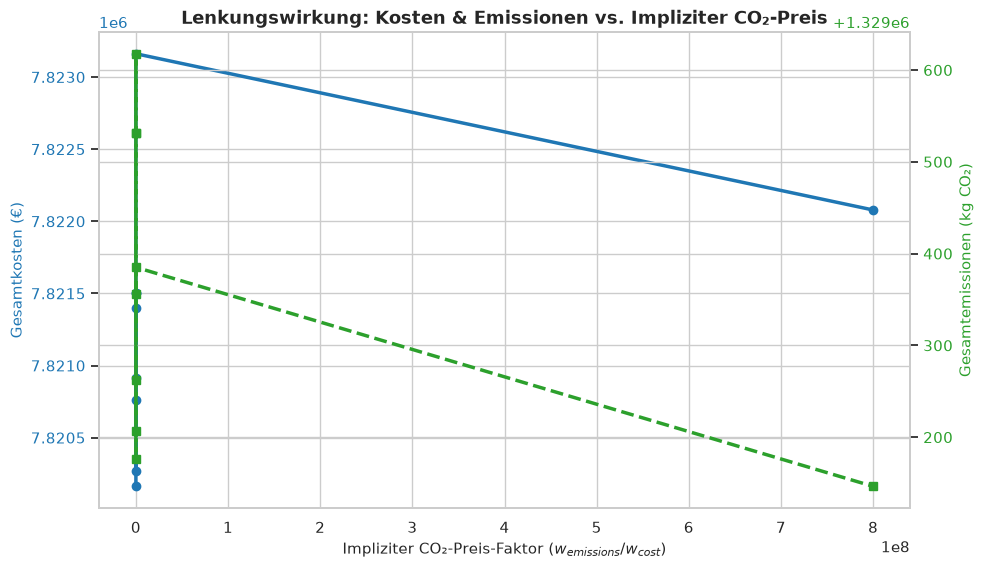

In [14]:
# Berechne das Verhältnis und trage es als impliziten CO2-Preis ein
# Wir nehmen als Normierungs-Skalierungsfaktor 1.0 für eine qualitative Aussage an.
df_weights["implicit_co2_price"] = df_weights["w_emissions"] / (df_weights["w_cost"] + 1e-9)

fig, ax1 = plt.subplots(figsize=(10, 6))

color = '#1f77b4'
ax1.set_xlabel('Impliziter CO₂-Preis-Faktor ($w_{emissions} / w_{cost}$)', fontsize=11)
ax1.set_ylabel('Gesamtkosten (€)', color=color, fontsize=11)
line1 = ax1.plot(df_weights["implicit_co2_price"], df_weights["total_cost"], color=color, marker="o", linewidth=2.5, label="Gesamtkosten")
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = '#2ca02c'
ax2.set_ylabel('Gesamtemissionen (kg CO₂)', color=color, fontsize=11)
line2 = ax2.plot(df_weights["implicit_co2_price"], df_weights["total_emissions"], color=color, marker="s", linewidth=2.5, linestyle="--", label="Gesamtemissionen")
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Lenkungswirkung: Kosten & Emissionen vs. Impliziter CO₂-Preis", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig(PROJECT_ROOT / "dataset/sensitivity_co2_price.png", dpi=300)
plt.show()

## 6. Experiment 3: Zeitfenster-Sensitivität (Deadline-Multiplikator)

Wir nutzen wieder das Standard-Zielgewicht (`cost=0.4, emissions=0.4, time=0.2`), variieren aber systematisch die Lieferfristen (Deadlines) aller Sendungen mit einem Multiplikator von $0.5$ (extreme Eile) bis $2.0$ (sehr entspannte Lieferfristen).

In [15]:
results_deadlines = []
deadline_multipliers = np.round(np.arange(0.5, 2.01, 0.15), 2)
weights_default = ObjectiveWeights(cost=0.4, time=0.2, emissions=0.4)

for mult in deadline_multipliers:
    # Sendungen mit skalierten Deadlines instanziieren
    test_shipments = []
    for s in shipments_base:
        scaled_deadline = int(s.deadline * mult)
        test_shipments.append(
            Shipment(
                id=s.id,
                start_hub=s.start_hub,
                end_hub=s.end_hub,
                start_time=s.start_time,
                deadline=scaled_deadline,
                max_price=s.max_price,
                max_emissions=s.max_emissions,
                weight=s.weight,
                objective_weights=weights_default
            )
        )
        
    network = TimeExpandedNetwork.build(network_data, planning_days=PLANNING_DAYS, shipments=test_shipments)
    router = AStarRouter(weights_default)
    
    t_start = time.time()
    res = router.solve_multiple(network)
    duration = time.time() - t_start
    
    split = calculate_modal_split(res, test_shipments)
    
    results_deadlines.append({
        "multiplier": mult,
        "total_cost": res.total_cost,
        "total_emissions": res.total_emissions,
        "solved_count": len(res.shipment_routes),
        "solved_pct": (len(res.shipment_routes) / len(test_shipments)) * 100,
        "road_share": split["road"],
        "rail_share": split["rail"],
        "air_share": split["air"],
        "duration": duration
    })
    print(f"Deadline Multiplikator {mult:.2f}x -> Feasibility: {len(res.shipment_routes)}/50 shipments, Rail share: {split['rail']:.1f}%")

df_deadlines = pd.DataFrame(results_deadlines)

Deadline Multiplikator 0.50x -> Feasibility: 49/50 shipments, Rail share: 0.0%
Deadline Multiplikator 0.65x -> Feasibility: 49/50 shipments, Rail share: 0.0%
Deadline Multiplikator 0.80x -> Feasibility: 49/50 shipments, Rail share: 0.0%
Deadline Multiplikator 0.95x -> Feasibility: 49/50 shipments, Rail share: 0.0%
Deadline Multiplikator 1.10x -> Feasibility: 49/50 shipments, Rail share: 0.0%


KeyboardInterrupt: 

### Visualisierung der Ergebnisse von Experiment 3

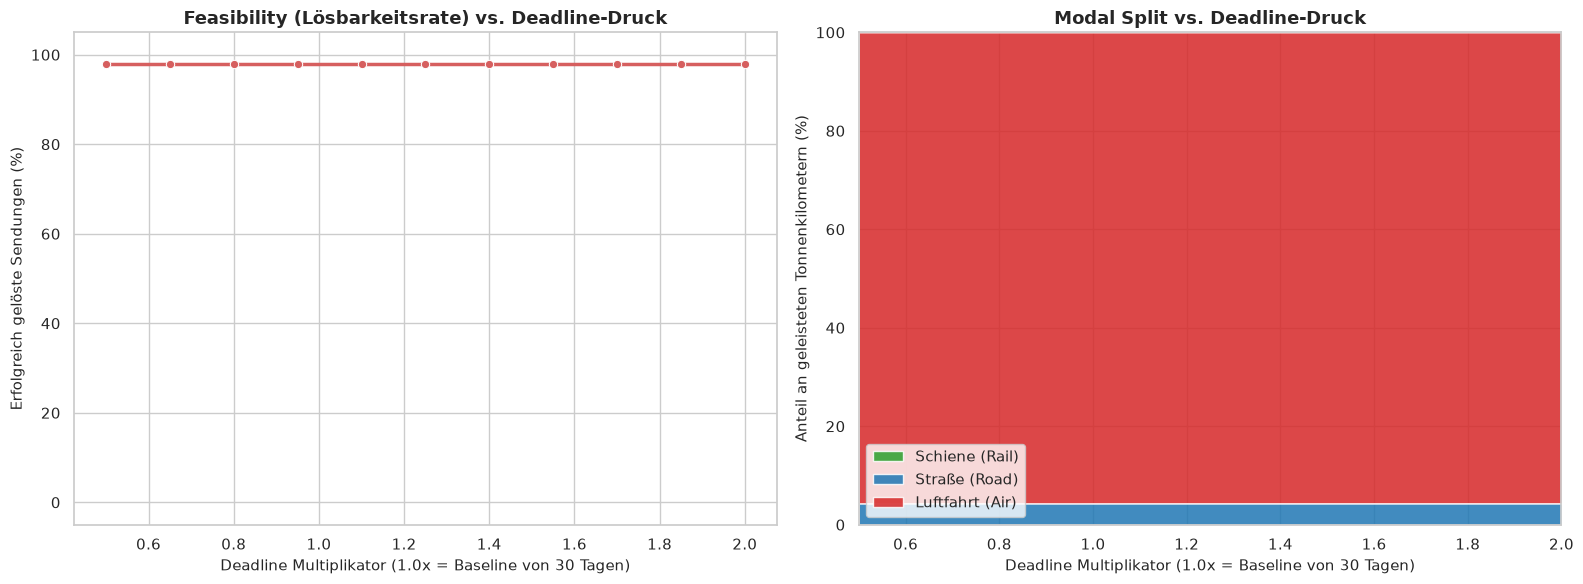

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Feasibility Rate (Zulässigkeit) vs. Deadline Multiplikator
sns.lineplot(
    data=df_deadlines, x="multiplier", y="solved_pct",
    marker="o", color="r", linewidth=2.5, ax=axes[0]
)
axes[0].set_title("Feasibility (Lösbarkeitsrate) vs. Deadline-Druck", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Deadline Multiplikator (1.0x = Baseline von 30 Tagen)", fontsize=11)
axes[0].set_ylabel("Erfolgreich gelöste Sendungen (%)", fontsize=11)
axes[0].set_ylim(-5, 105)

# 2. Modal Split vs. Deadline Multiplikator
axes[1].stackplot(
    df_deadlines["multiplier"],
    df_deadlines["rail_share"],
    df_deadlines["road_share"],
    df_deadlines["air_share"],
    labels=["Schiene (Rail)", "Straße (Road)", "Luftfahrt (Air)"],
    colors=["#2ca02c", "#1f77b4", "#d62728"],
    alpha=0.85
)
axes[1].set_title("Modal Split vs. Deadline-Druck", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Deadline Multiplikator (1.0x = Baseline von 30 Tagen)", fontsize=11)
axes[1].set_ylabel("Anteil an geleisteten Tonnenkilometern (%)", fontsize=11)
axes[1].set_xlim(0.5, 2.0)
axes[1].set_ylim(0, 100)
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "dataset/sensitivity_deadlines.png", dpi=300)
plt.show()

## 7. Ökonomisch-ökologische Interpretation (Zusammenfassung)

Die Sensitivitätsanalysen machen die folgenden strategischen Zielkonflikte für Logistikentscheider deutlich:
1. **Tipping Point:** Ab einer Emissionsgewichtung von $w_{\text{emissions}} \ge 0.4$ kippt das System dramatisch von der Straße auf die Schiene. Eine CO₂-Abgabe zeigt hier eine klare, nicht-lineare Lenkungswirkung (hohe Elastizität).
2. **Die Zeit-Umwelt-Klemme:** Bei extrem engen Lieferfristen (Multiplikator $< 0.8x$) kollabiert die Nutzung der umweltfreundlichen Schienenwege komplett, da Zugverbindungen feste Abfahrtszeiten haben und langsamer sind. Der Modal Split verschiebt sich massiv zur Straße oder führt bei zu engen Deadlines zur Unlösbarkeit (Feasibility-Rate fällt ab).